# 34 Compare StyleGAN3 Two Datasets (3 CNN Seeds)

This notebook compares the saved baseline, StyleGAN2-ADA, and StyleGAN3-T patch-level results from DIBaS and dataset 2.


In [1]:
from pathlib import Path
import csv
import json
import shutil

import matplotlib.pyplot as plt

import pandas as pd

from IPython.display import display

# This helper keeps the notebook easy to run from the repo root or from notebooks/.
def find_repo_root(start_path: Path) -> Path:
    if (start_path / "raw_data").exists():
        return start_path
    if start_path.name == "notebooks" and (start_path.parent / "raw_data").exists():
        return start_path.parent
    raise FileNotFoundError("Could not find the FYP2 repo root.")

REPO_ROOT = find_repo_root(Path.cwd())
RESULTS_DIR = REPO_ROOT / "results"
NOTEBOOK_TAG = "34_compare_stylegan3_two_datasets"
NOTEBOOK_RESULTS_DIR = RESULTS_DIR / NOTEBOOK_TAG
NOTEBOOK_FIGURES_DIR = NOTEBOOK_RESULTS_DIR / "figures"

# Compare notebooks are quick to rebuild, so clear only this notebook's old comparison outputs.
if NOTEBOOK_RESULTS_DIR.exists():
    shutil.rmtree(NOTEBOOK_RESULTS_DIR)
NOTEBOOK_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DIBAS_MODEL_PATH = RESULTS_DIR / "32_compare_stylegan3_results_dibas" / "model_comparison.csv"
DATASET2_MODEL_PATH = RESULTS_DIR / "33_compare_stylegan3_results_dataset2" / "model_comparison.csv"

In [2]:
# This helper reads a CSV file into a plain list of rows.
def read_csv_rows(csv_path: Path):
    with csv_path.open("r", newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

# This helper writes a CSV file with a stable header.
def write_csv_rows(csv_path: Path, rows, fieldnames):
    if not rows:
        raise ValueError(f"No rows were provided for {csv_path.name}.")
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    with csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

# This helper writes one small JSON file with clean formatting.
def write_json(json_path: Path, data):
    json_path.parent.mkdir(parents=True, exist_ok=True)
    json_path.write_text(json.dumps(data, indent=2), encoding="utf-8")

,run_tag,model_name,model_display_name,training_mode,seed_count,fold_count,run_count,mean_accuracy,std_accuracy,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_precision,std_macro_precision,mean_macro_recall,std_macro_recall,mean_macro_f1,std_macro_f1,dataset_name
0,05_resnet50_baseline_dibas,resnet50,ResNet-50,baseline,3,5,15,0.990858,0.00596,0.990118,0.007422,0.991155,0.004776,0.990118,0.007422,0.990553,0.006217,dibas
1,06_resnet50_gan_dibas,resnet50,ResNet-50,gan,3,5,15,0.994551,0.002009,0.99427,0.002446,0.994509,0.001748,0.99427,0.002446,0.994381,0.002077,dibas
2,26_resnet50_stylegan3_dibas,resnet50,ResNet-50,stylegan3,3,5,15,0.99388,0.003524,0.993354,0.004413,0.994073,0.002842,0.993354,0.004413,0.993683,0.003657,dibas
3,07_efficientnetv2s_baseline_dibas,efficientnetv2s,EfficientNetV2-S,baseline,3,5,15,0.995126,0.002448,0.995139,0.002186,0.994844,0.002874,0.995139,0.002186,0.994979,0.002514,dibas
4,08_efficientnetv2s_gan_dibas,efficientnetv2s,EfficientNetV2-S,gan,3,5,15,0.995796,0.001556,0.995681,0.001541,0.995673,0.001794,0.995681,0.001541,0.995668,0.001601,dibas
5,27_efficientnetv2s_stylegan3_dibas,efficientnetv2s,EfficientNetV2-S,stylegan3,3,5,15,0.995445,0.00331,0.995237,0.004095,0.995405,0.002714,0.995237,0.004095,0.9953,0.003434,dibas
6,09_convnextv2nano_baseline_dibas,convnextv2nano,ConvNeXtV2-Nano,baseline,3,5,15,0.989645,0.009794,0.989522,0.008354,0.989505,0.010761,0.989522,0.008354,0.989359,0.009945,dibas
7,10_convnextv2nano_gan_dibas,convnextv2nano,ConvNeXtV2-Nano,gan,3,5,15,0.990038,0.004579,0.989468,0.005544,0.99009,0.004057,0.989468,0.005544,0.98972,0.004756,dibas
8,28_convnextv2nano_stylegan3_dibas,convnextv2nano,ConvNeXtV2-Nano,stylegan3,3,5,15,0.989942,0.005132,0.989247,0.00532,0.9901,0.005431,0.989247,0.00532,0.989627,0.005284,dibas
9,15_resnet50_baseline_dataset2,resnet50,ResNet-50,baseline,3,5,15,0.991274,0.003467,0.991482,0.002911,0.990785,0.004098,0.991482,0.002911,0.9911,0.003519,dataset2


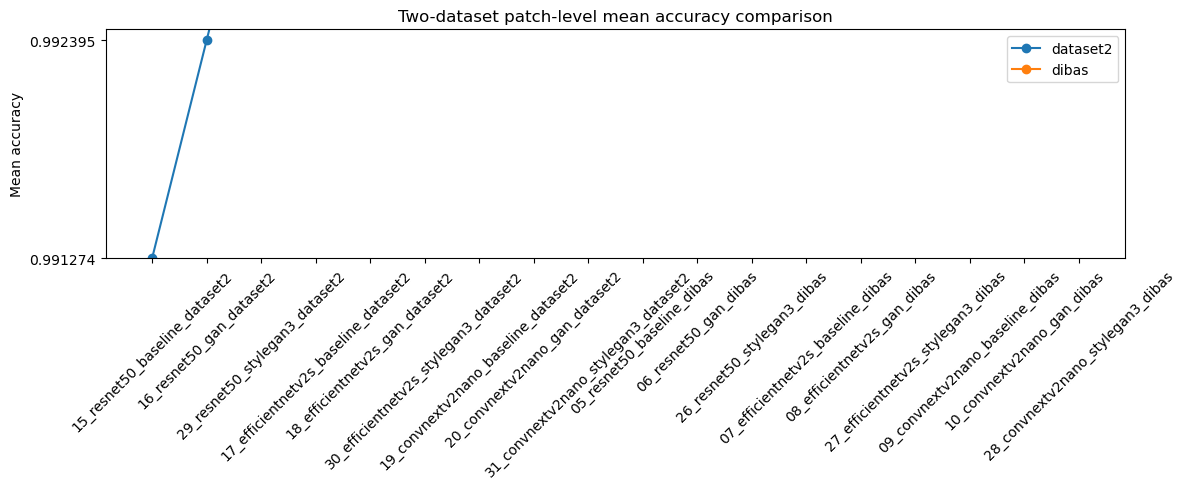

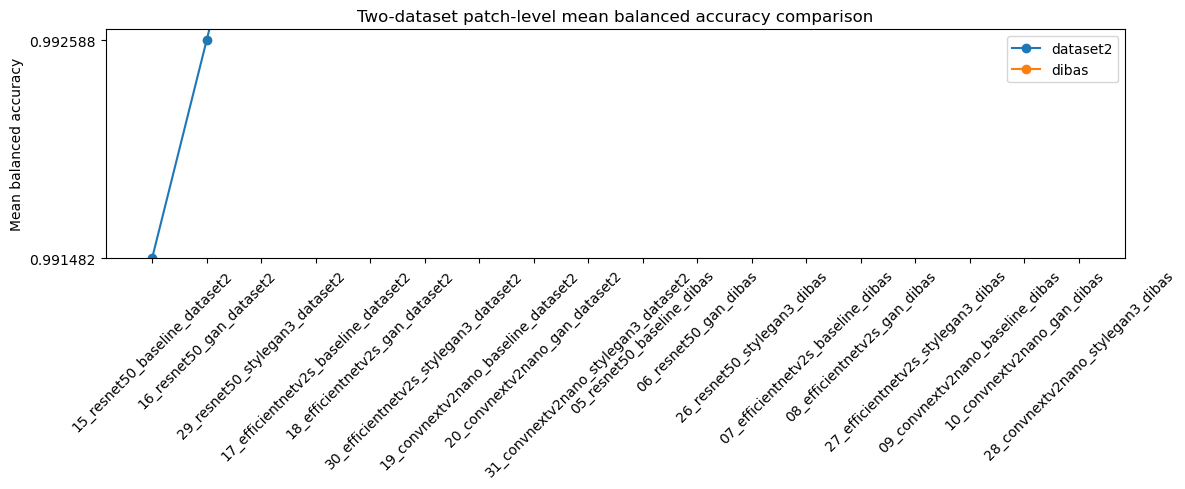

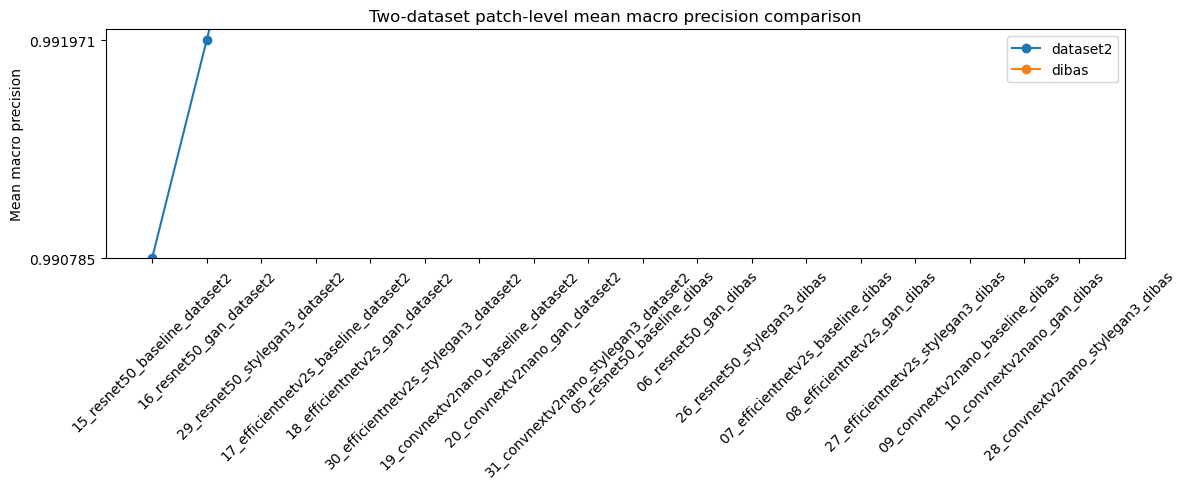

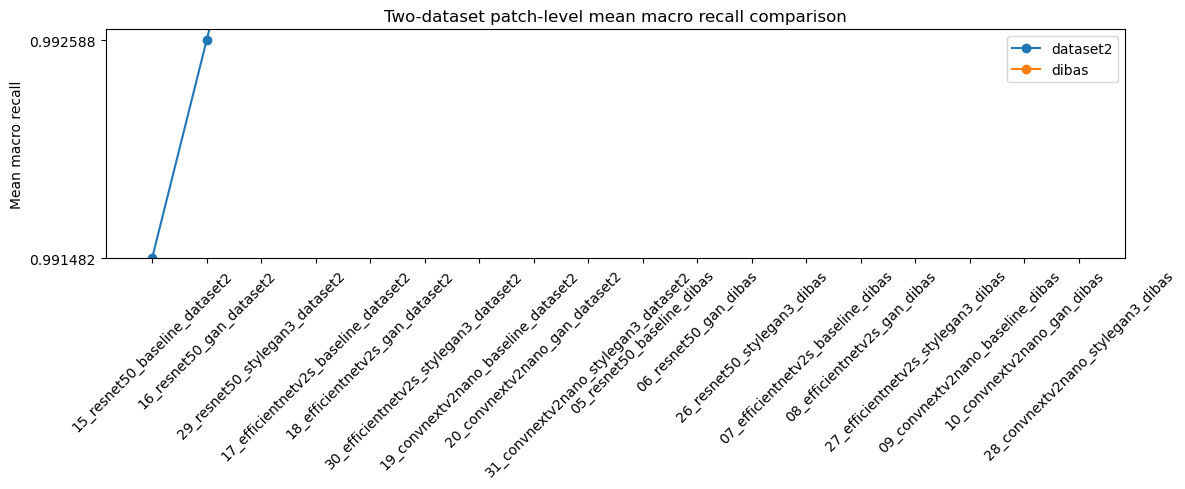

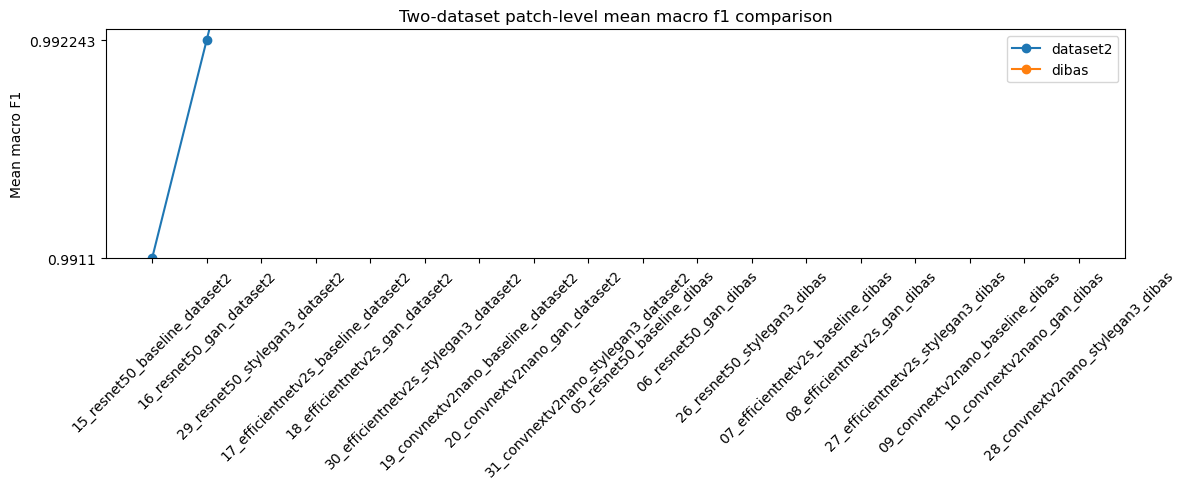

In [3]:
dibas_rows = read_csv_rows(DIBAS_MODEL_PATH)
dataset2_rows = read_csv_rows(DATASET2_MODEL_PATH)

combined_rows = []
for row in dibas_rows:
    combined_row = dict(row)
    combined_row["dataset_name"] = "dibas"
    combined_rows.append(combined_row)
for row in dataset2_rows:
    combined_row = dict(row)
    combined_row["dataset_name"] = "dataset2"
    combined_rows.append(combined_row)

write_csv_rows(NOTEBOOK_RESULTS_DIR / "combined_model_comparison.csv", combined_rows, list(combined_rows[0].keys()))
write_json(NOTEBOOK_RESULTS_DIR / "summary.json", {"notebook_tag": NOTEBOOK_TAG, "row_count": len(combined_rows)})

combined_df = pd.DataFrame(combined_rows)
display(combined_df)

metric_plot_specs = [
    ("mean_accuracy", "two_dataset_accuracy.png", "Mean accuracy"),
    ("mean_balanced_accuracy", "two_dataset_balanced_accuracy.png", "Mean balanced accuracy"),
    ("mean_macro_precision", "two_dataset_macro_precision.png", "Mean macro precision"),
    ("mean_macro_recall", "two_dataset_macro_recall.png", "Mean macro recall"),
    ("mean_macro_f1", "two_dataset_macro_f1.png", "Mean macro F1"),
]
for metric_name, file_name, axis_label in metric_plot_specs:
    fig, axis = plt.subplots(figsize=(12, 5))
    for dataset_name in sorted(combined_df["dataset_name"].unique()):
        current = combined_df[combined_df["dataset_name"] == dataset_name]
        axis.plot(current["run_tag"], current[metric_name], marker="o", label=dataset_name)
    axis.set_ylim(0.0, 1.05)
    axis.set_ylabel(axis_label)
    axis.set_title(f"Two-dataset patch-level {axis_label.lower()} comparison")
    axis.tick_params(axis="x", rotation=45)
    axis.legend()
    fig.tight_layout()
    fig.savefig(NOTEBOOK_FIGURES_DIR / file_name, dpi=200)
    plt.show()